In [1]:
import cv2
import rerun
import matplotlib.pyplot as plt

print(cv2.__version__)
print(rerun.__version__)

5.0.0
0.36.0


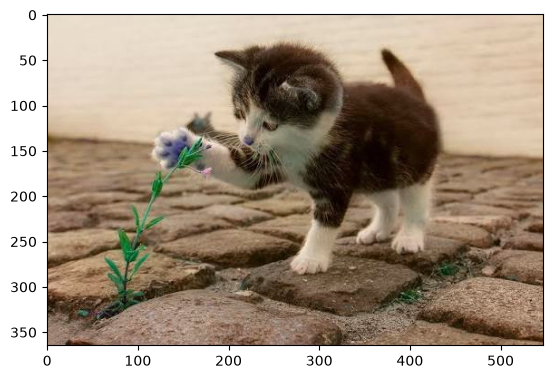

In [2]:
image = cv2.imread("gatito.jpeg")
plt.imshow(image)

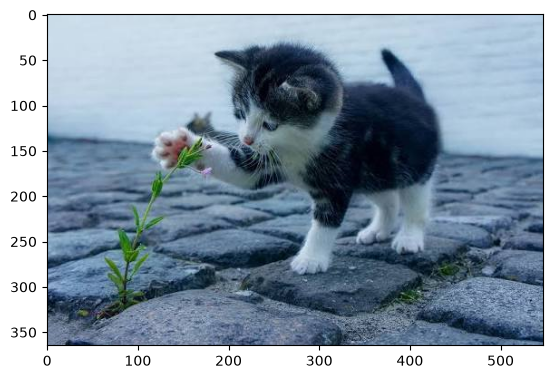

In [3]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)

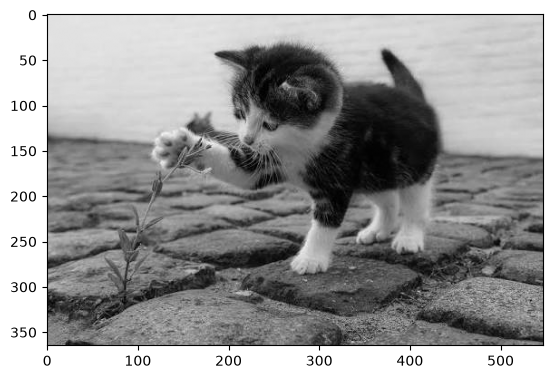

In [4]:
img_gray = cv2.imread("gatito.jpeg", cv2.IMREAD_GRAYSCALE)
plt.imshow(img_gray, cmap='gray')

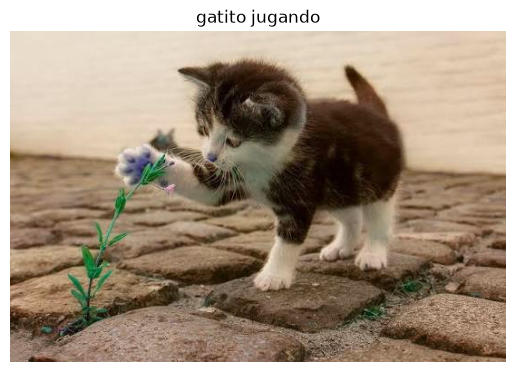

In [5]:
img_alpha = cv2.imread('gatito.jpeg', cv2.IMREAD_UNCHANGED)

plt.imshow(img_alpha)
plt.axis('off')
plt.title('gatito jugando')
plt.show()


In [6]:
cv2.imwrite("nueva_imagen.png", image)

True

In [7]:
print(image)

[[[232 220 202]
  [232 220 202]
  [232 220 202]
  ...
  [226 206 181]
  [226 206 181]
  [226 206 181]]

 [[232 220 202]
  [232 220 202]
  [232 220 202]
  ...
  [226 206 181]
  [226 206 181]
  [226 206 181]]

 [[232 220 202]
  [232 220 202]
  [232 220 202]
  ...
  [226 206 181]
  [226 206 181]
  [226 206 181]]

 ...

 [[156 130 114]
  [162 136 120]
  [164 138 122]
  ...
  [158 127 104]
  [158 127 104]
  [159 128 105]]

 [[155 129 113]
  [165 139 123]
  [168 142 126]
  ...
  [149 118  93]
  [148 118  93]
  [149 117  94]]

 [[154 128 112]
  [160 134 118]
  [159 133 117]
  ...
  [149 116  90]
  [144 114  87]
  [142 108  84]]]


In [8]:
print(image.shape)

(365, 547, 3)


In [9]:
print(type(image))

<class 'numpy.ndarray'>


In [10]:
print(image.ndim)

3


In [11]:
print(image.size)

598965


# Indexing 

In [12]:
# [filas, columnas]

print(image[250, 150])

pixels = image[250,150]
print("pixeles: ", pixels)

b, g, r = image[250,150]
print(f"R: {r}, G: {g}, B:{b}")

[172 145 118]
pixeles:  [172 145 118]
R: 118, G: 145, B:172


(365, 547, 3)


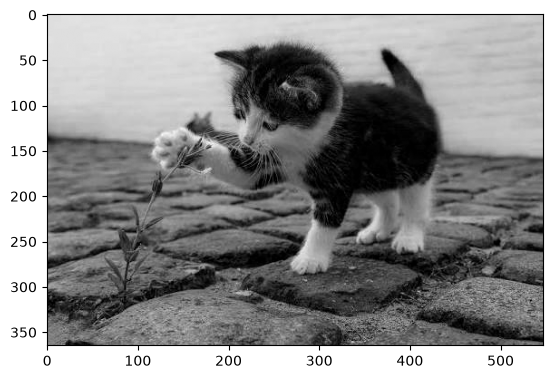

In [16]:
print(image.shape)
canal_azul = image[:,:,0]
canal_verde = image[:,:,1]
canal_rojo = image[:,:,2]

plt.imshow(canal_rojo, cmap="gray")

In [18]:
print(canal_azul[300, 400])
print(canal_verde[300,400])
print(canal_rojo[300,400])
print(image[300,400])

50
43
23
[50 43 23]


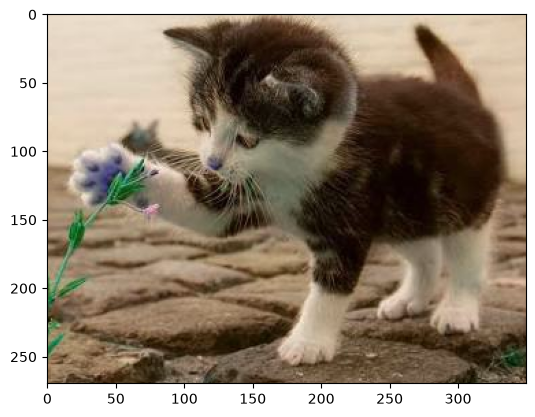

In [20]:
roi = image[30:300, 100:450]
plt.imshow(roi)

(270, 350, 3)


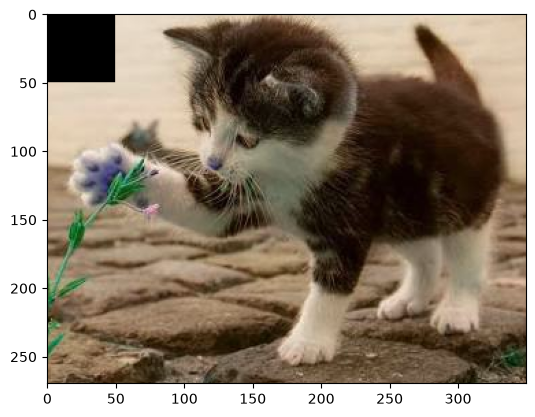

In [22]:
print(roi.shape)

roi[0:50, 0:50] = 0
plt.imshow(roi)

# Espacios de color

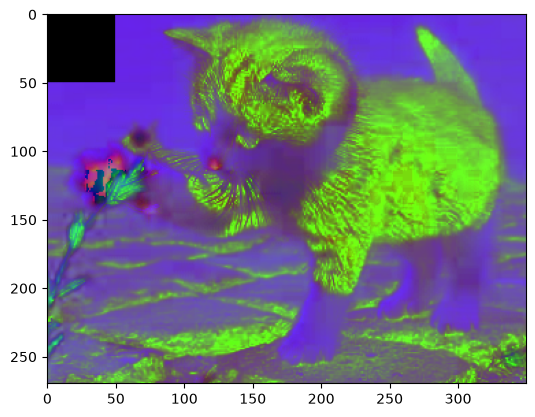

In [23]:
roi_hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
plt.imshow(roi_hsv)

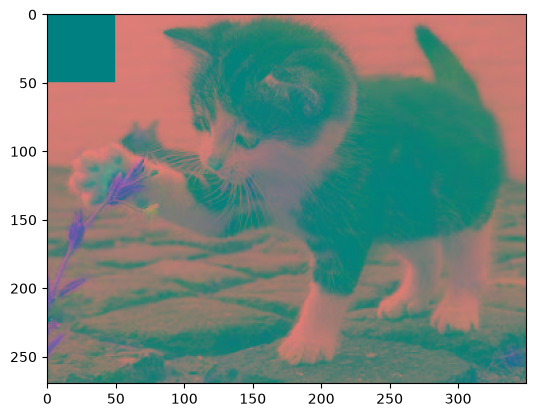

In [25]:
roi_lab = cv2.cvtColor(roi, cv2.COLOR_BGR2LAB)
plt.imshow(roi_lab)

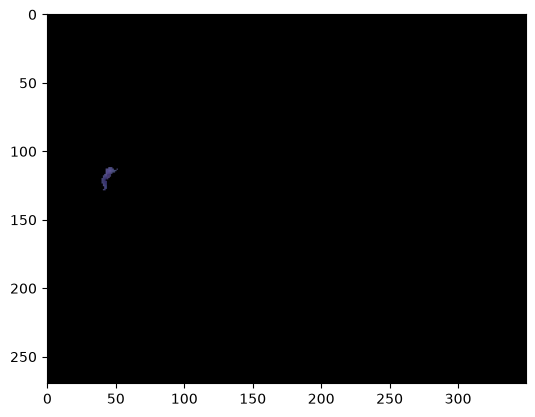

In [28]:

import numpy as np

bajo1 = np.array([0, 100, 100]); alto1 = np.array([10, 255, 255])
bajo2 = np.array([160, 100, 100]); alto2 = np.array([179, 255, 255])
mascara = cv2.inRange(roi_hsv, bajo1, alto1) | cv2.inRange(roi_hsv, bajo2, alto2)
resultado = cv2.bitwise_and(roi, roi, mask=mascara)

plt.imshow(resultado)

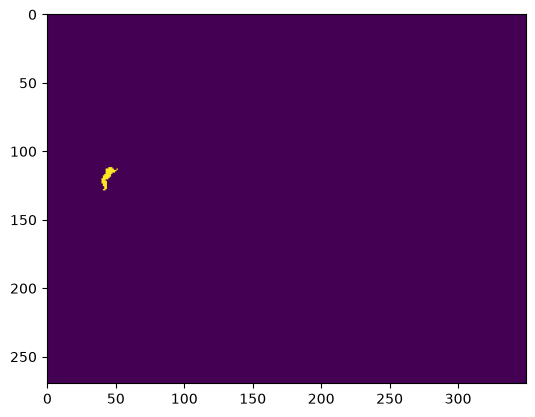

In [29]:
plt.imshow(mascara)

In [33]:
print(roi.min())
print(roi.max())
print(roi.mean())
print(roi.std())

0
255
103.11037742504409
66.53008840656148


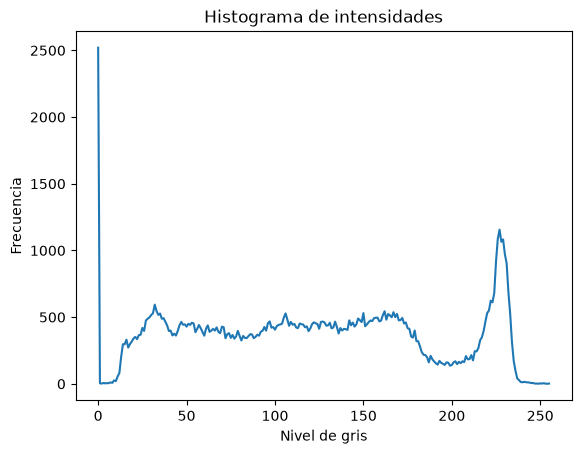

In [35]:
hist = cv2.calcHist([roi], [0], None, [256], [0, 256])

plt.plot(hist)
plt.title("Histograma de intensidades")
plt.xlabel("Nivel de gris"); plt.ylabel("Frecuencia")
plt.show()

hist_np, bins = np.histogram(roi.ravel(), bins=256, range=(0, 256))

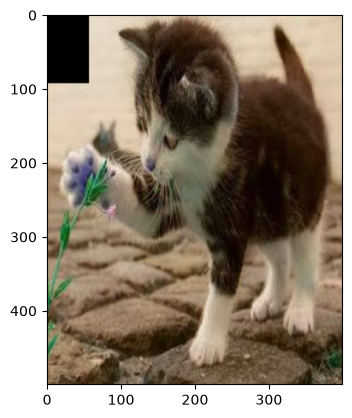

In [39]:
roi_grande = cv2.resize(roi, (400, 500))
plt.imshow(roi_grande)

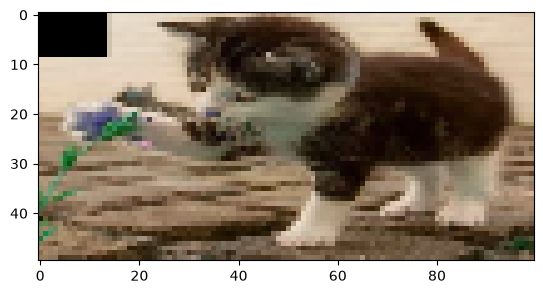

In [41]:
roi_pequenio = cv2.resize(roi, (100,50))
plt.imshow(roi_pequenio)

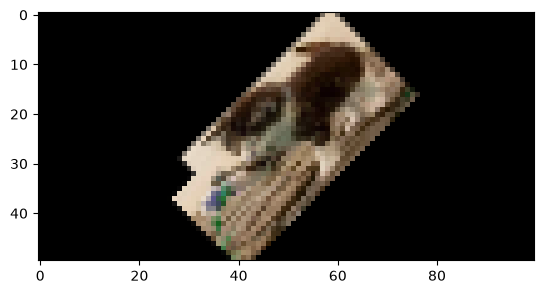

In [44]:
(h, w) = roi_pequenio.shape[:2]
centro = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(centro, angle=45, scale=0.5)
rotada = cv2.warpAffine(roi_pequenio, M, (w, h))

plt.imshow(rotada)
